In [1]:
from pathlib import Path
import warnings
import gc
import torch
import os
import time
import random
import subprocess
import json
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import cosine
import pandas as pd
import seaborn as sns

In [ ]:
def read_weights(filename):
    weights_dict = {}
    current_language = None
    weights = []

    with open(filename, 'r') as file:
        for line in file:
            if line.startswith("Model:"):
                if current_language and weights:
                    weights_dict[current_language] = np.array(weights)
                parts = line.split(',')
                current_language = None
                weights = []
                for part in parts:
                    if part.strip().startswith("Language:"):
                        current_language = part.split(': ')[-1].strip()
            elif any(char.isdigit() for char in line):  # Check if line contains digits
                clean_line = line.replace(']', '').replace('[', '').replace(',', '').strip()
                if clean_line:
                    weights.append(list(map(float, clean_line.split())))

        if current_language and weights:
            weights_dict[current_language] = np.array(weights)

    return weights_dict

def cosine_similarity(weights1, weights2):
    similarities = []
    for w1, w2 in zip(weights1, weights2):
        similarity = 1 - cosine(w1, w2)
        similarities.append(similarity)
    return np.mean(similarities)

In [5]:
def print_weights_layers(dataset, model):
    # Model name mapping
    model_name_refresh = {
        "google/gemma-7b": "gemma-7b", "google/gemma-2b": "gemma-2b",
        "meta-llama/Llama-2-7b-chat-hf": "Llama-7b", "meta-llama/Llama-2-13b-chat-hf": "Llama-13b",
        "meta-llama/Llama-2-70b-chat-hf": "Llama-70b", "Qwen/Qwen1.5-0.5B": "Qwen-0.5B",
        "Qwen/Qwen1.5-1.8B": "Qwen-1.8B", "Qwen/Qwen1.5-4B": "Qwen-4B",
        "Qwen/Qwen1.5-7B": "Qwen-7B", "Qwen/Qwen1.5-14B": "Qwen-14B",
        "Qwen/Qwen1.5-72B": "Qwen-72B"
    }
    model_name = model_name_refresh[model]
    
    model_2_layer = {
        "google/gemma-7b": 28, "google/gemma-2b": 18, "meta-llama/Llama-2-7b-chat-hf": 32,
        "meta-llama/Llama-2-13b-chat-hf": 40, "meta-llama/Llama-2-70b-chat-hf": 80,
        "Qwen/Qwen1.5-0.5B": 24, "Qwen/Qwen1.5-1.8B": 24, "Qwen/Qwen1.5-4B": 40, 
        "Qwen/Qwen1.5-7B": 32, "Qwen/Qwen1.5-14B": 40, "Qwen/Qwen1.5-72B": 80
    }

    # Language abbreviation mapping
    language_abbreviations = {
        'English': 'EN', 'German': 'DE', 'French': 'FR', 'Chinese': 'ZH', 'Spanish': 'ES', 
        'Russian': 'RU', 'Indonesian': 'ID', 'Oriya': 'OR', 'Hindi': 'HI', 'Burmese': 'MY', 
        'Hawaiian': 'HW', 'Kannada': 'KN', 'Tamil': 'TA', 'Telugu': 'TE', 'Kazakh': 'KK', 'Turkmen': 'TK'
    }

    # Desired language order (use abbreviations)
    language_order = ['EN', 'DE', 'FR', 'ZH', 'ES', 'RU', 'ID', 'OR', 'HI', "KN", 'MY', 'HW', 'TA', 'TE', 'KK', 'TK']

    for i in reversed(range(model_2_layer[model])):
        print(i)
#         if model == "Qwen/Qwen1.5-1.8B" or model == "Qwen/Qwen1.5-0.5B":
#             i = 23
#         else:
#             i = 17
        filename = 'results/weights/opinion/' + dataset + '_' + model_name + '_' + str(i) + '.txt'
#         filename = 'results_new/weights/opinion/' + dataset + '_' + model_name + '_' + str(i) + '_new.txt'
        weights_dict = read_weights(filename)
        plt.rcParams['font.family'] = 'Times New Roman'

        # Calculate similarities for each language pair
        languages = list(weights_dict.keys())
        similarity_data = {lang: [] for lang in languages}

        for ref_language in languages:
            ref_weights = weights_dict[ref_language]
            for language in languages:
                similarity = cosine_similarity(ref_weights, weights_dict[language])
                similarity_data[ref_language].append(similarity)

        # Convert to DataFrame
        df = pd.DataFrame(similarity_data, index=languages, columns=languages)

        # Reorder DataFrame according to the desired language order (abbreviations)
        df.rename(index=language_abbreviations, columns=language_abbreviations, inplace=True)
        df = df.reindex(index=language_order, columns=language_order)

        # Fill the diagonal with 1
        np.fill_diagonal(df.values, 1)

        # Set up the matplotlib figure
        plt.figure(figsize=(6, 5))  # Adjust figure size to make it square

        # Draw the complete heatmap (no mask)
        ax = sns.heatmap(
            df,
            cmap='Oranges',
            annot=True,
            fmt=".1f",  # Display three decimal places
            annot_kws={"size": 11},  # Adjust font size
            linewidths=.5,
            cbar_kws={"shrink": .5}
        )

        # Highlight the top 6 y-ticks
        for tick in ax.yaxis.get_major_ticks()[:7]:
            tick.label1.set_fontweight('bold')

        # Highlight the leftmost 6 x-ticks
        for tick in ax.xaxis.get_major_ticks()[:7]:
            tick.label1.set_fontweight('bold')

        plt.xticks(fontsize=12)  # Rotate x-axis labels for better readability
        plt.yticks(fontsize=12, rotation=90)

        m_name = model_name
        if model_name == 'gemma-2b':
            m_name = 'Gemma-2B'
        if model_name == 'gemma-7b':
            m_name = 'Gemma-7B'
        if dataset == 'opinion':
            plt.title(f'{m_name} on Opinion', fontsize=16)
        if dataset == 'cities':
            plt.title(f'{m_name} on Cities', fontsize=16)

        plt.tight_layout()

        # Save plot as a PDF file
        save_path = f'results/weights/{model_name}_{dataset}_exp2_art.jpg'
        plt.savefig(save_path, format='jpg', dpi=300, bbox_inches='tight')

        # Show plot
        plt.show()
        break

23


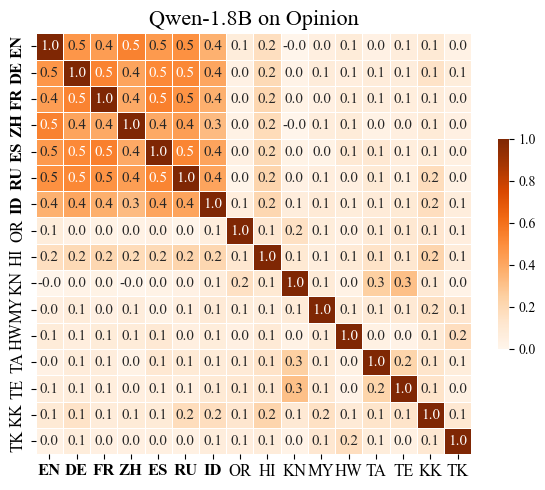

In [6]:
# Example usage
print_weights_layers('opinion', "Qwen/Qwen1.5-1.8B")

opinion Qwen/Qwen1.5-7B
31


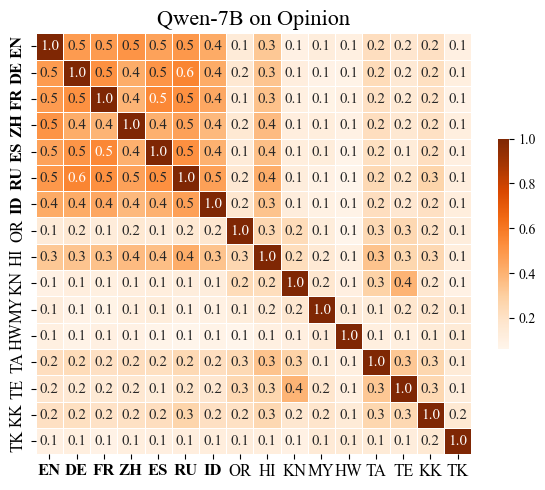

opinion google/gemma-7b
27


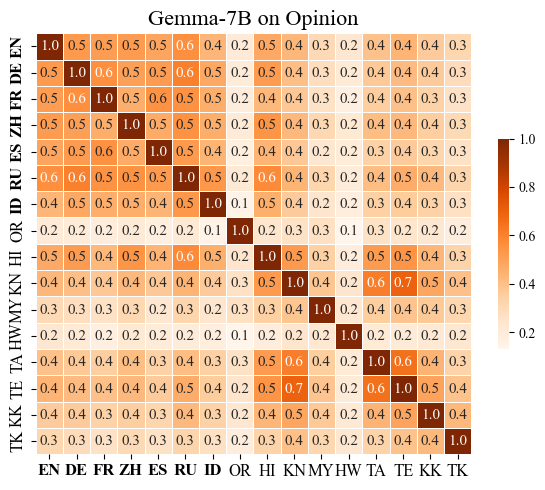

cities Qwen/Qwen1.5-7B
31


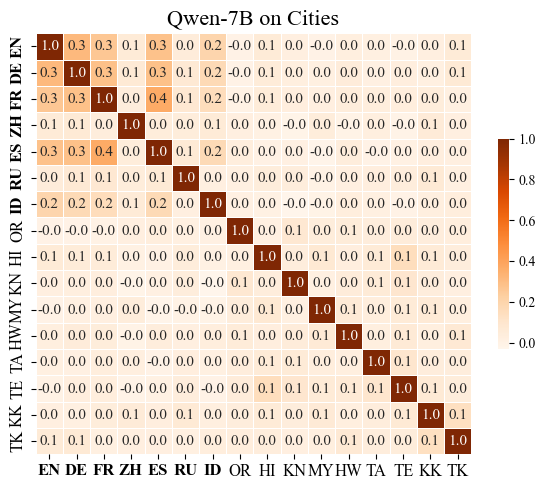

cities google/gemma-7b
27


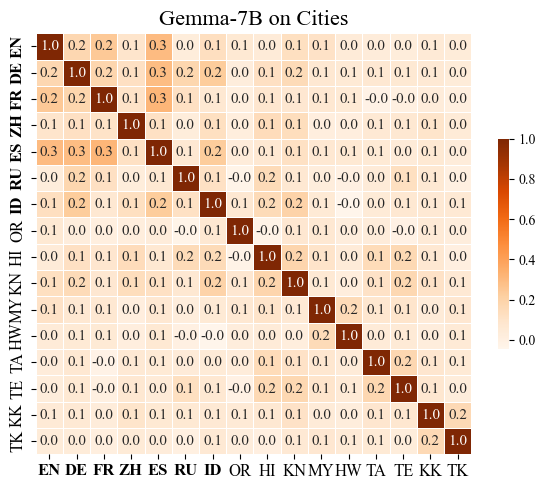

In [11]:
dataset = ['opinion', 'cities']
model = ['Qwen/Qwen1.5-1.8B', 'Qwen/Qwen1.5-0.5B', "google/gemma-2b"]
model = ['Qwen/Qwen1.5-7B', 'google/gemma-7b']
for d in dataset:
    for m in model:
        print(d, m)
        print_weights_layers(d, m)

In [2]:
def read_weights(filename):
    weights_dict = {}
    current_language = None
    weights = []

    with open(filename, 'r') as file:
        for line in file:
            # Detect a new model and language block
            if line.startswith("Model:"):
                # Extract weights if already gathered for previous language
                if current_language and weights:
                    flattened_weights = [item for sublist in weights for item in sublist]
                    weights_dict[current_language] = np.array(flattened_weights)
                
                # Reset for new language and model
                parts = line.split(',')
                current_language = None
                weights = []
                
                for part in parts:
                    if part.strip().startswith("Language:"):
                        current_language = part.split(': ')[-1].strip()
                    if part.strip().startswith("Weights:"):
                        # Handle weights on the same line as "Model"
                        clean_line = part.replace('Weights:', '').replace('[', '').replace(']', '').strip()
                        if clean_line:
                            weights.append(list(map(float, clean_line.split())))

            # Process any subsequent lines containing weights
            elif any(char.isdigit() for char in line):
                clean_line = line.replace(']', '').replace('[', '').replace(',', '').strip()
                if clean_line:
                    weights.append(list(map(float, clean_line.split())))

        # Ensure the last language block is added to the dictionary
        if current_language and weights:
            flattened_weights = [item for sublist in weights for item in sublist]
            weights_dict[current_language] = np.array(flattened_weights)

    return weights_dict

def cosine_similarity(weights1, weights2):
    # 直接计算两个一维向量的余弦相似度
    similarity = 1 - cosine(weights1, weights2)
    return similarity

In [27]:
# EXP 2 Part 2

In [36]:
def read_weights(filename):
    weights_dict = {}
    current_language = None
    weights = []

    with open(filename, 'r') as file:
        for line in file:
            if line.startswith("Model:"):
                if current_language and weights:
                    # Flatten the weights list and convert to a 1D numpy array
                    flattened_weights = [item for sublist in weights for item in sublist]
                    weights_dict[current_language] = np.array(flattened_weights)
                parts = line.split(',')
                current_language = None
                weights = []
                for part in parts:
                    if part.strip().startswith("Language:"):
                        current_language = part.split(': ')[-1].strip()
            elif any(char.isdigit() for char in line):  # Check if line contains digits
                clean_line = line.replace(']', '').replace('[', '').replace(',', '').strip()
                if clean_line:
                    weights.append(list(map(float, clean_line.split())))

        if current_language and weights:
            # Flatten the weights list for the last entry and convert to a 1D numpy array
            flattened_weights = [item for sublist in weights for item in sublist]
            weights_dict[current_language] = np.array(flattened_weights)

    return weights_dict

In [7]:
def print_weights_layers(dataset, model):
    # 更新模型名称映射
    model_name_refresh = {"google/gemma-7b": "gemma-7b", "google/gemma-2b": "gemma-2b",
                          "meta-llama/Llama-2-7b-chat-hf": "Llama-7b",
                          "meta-llama/Llama-2-13b-chat-hf": "Llama-13b",
                          "meta-llama/Llama-2-70b-chat-hf": "Llama-70b", 
                          "Qwen/Qwen1.5-0.5B": "Qwen-0.5B",
                          "Qwen/Qwen1.5-1.8B": "Qwen-1.8B", "Qwen/Qwen1.5-4B": "Qwen-4B",
                          "Qwen/Qwen1.5-7B": "Qwen-7B", "Qwen/Qwen1.5-14B": "Qwen-14B",
                          "Qwen/Qwen1.5-72B": "Qwen-72B"}
    model_name = model_name_refresh[model]
    
    # 模型对应层数
    model_2_layer = {"google/gemma-7b": 28, "google/gemma-2b": 18, "meta-llama/Llama-2-7b-chat-hf": 32,
                     "meta-llama/Llama-2-13b-chat-hf": 40, "meta-llama/Llama-2-70b-chat-hf": 80,
                     "Qwen/Qwen1.5-0.5B": 24, "Qwen/Qwen1.5-1.8B": 24, "Qwen/Qwen1.5-4B": 40, 
                     "Qwen/Qwen1.5-7B": 32, "Qwen/Qwen1.5-14B": 40, "Qwen/Qwen1.5-72B": 80}
    
    # 使用的语言列表
    language_abbreviations = [
        'English', 'German', 'French', 'Chinese', 'Spanish', 
        'Russian', 'Indonesian', 'Oriya', 'Hindi', 'Burmese', 
        'Hawaiian', 'Kannada', 'Tamil', 'Telugu', 'Kazakh', 'Turkmen'
    ]
    
    # 存储不同语言在各个层的相似度
    language_similarities = {lang: [] for lang in language_abbreviations}

    # 迭代层
    for i in range(model_2_layer[model]):
        filename = 'results/weights/opinion/' + dataset + '_' + model_name + '_' + str(i) + '.txt'
        filename = 'results_new/weights/opinion/' + dataset + '_' + model_name + '_' + str(i) + '_new.txt'
        
        weights_dict = read_weights(filename)

        # 只计算 English 与其他语言的相似度
        languages = list(weights_dict.keys())
        if "English" not in languages:
            continue  # 如果没有 English 这门语言，跳过此层

        ref_weights = weights_dict["English"]

        for language in language_abbreviations:
            if language not in weights_dict:
                continue  # 如果权重文件中没有该语言，跳过
            
            if language == "English":
                continue  # 跳过 English 自身的比较
            
            # 计算 English 与其他语言的相似度
            similarity = cosine_similarity(ref_weights, weights_dict[language])
            
            # 将相似度存储到字典中，按语言记录每层的相似度
            language_similarities[language].append(similarity)
    
    # 实线的语言
    solid_line_languages = ['English', 'German', 'French', 'Chinese', 'Spanish', 'Russian', 'Indonesian']

    # 绘制相似度随层变化的曲线图
    plt.figure(figsize=(8, 6))
    plt.rcParams['font.family'] = 'Times New Roman'

    # X轴是模型层的索引
    layers = list(reversed(range(model_2_layer[model])))

    # 绘制每种语言的曲线，按照给定的顺序
    for language in language_abbreviations:
        if len(language_similarities[language]) > 0:
            if language in solid_line_languages:
                plt.plot(layers[:len(language_similarities[language])], language_similarities[language], label=language, linestyle='-')  # 实线
            else:
                plt.plot(layers[:len(language_similarities[language])], language_similarities[language], label=language, linestyle='--')  # 虚线

    # 设置整数点的X轴刻度
    plt.xticks(layers, [str(layer) for layer in layers])

    # 设置图表标题和标签
    plt.grid(True, linestyle='--', alpha=0.6)
    if model_name == 'gemma-2b':
        m_name = 'Gemma-2B'
    m_name = model_name
    if dataset == 'opinion':
        plt.title(f'{m_name} on Opinion', fontsize=16)
    if dataset == 'cities':
        plt.title(f'{m_name} on Cities', fontsize=16)
    
    # 按指定顺序生成图例
    handles, labels = plt.gca().get_legend_handles_labels()
    sorted_handles_labels = sorted(zip(handles, labels), key=lambda x: language_abbreviations.index(x[1]))
    sorted_handles, sorted_labels = zip(*sorted_handles_labels)
    
    # 将图例放置在图表右侧内部
    plt.legend(sorted_handles, sorted_labels, loc='center left', fontsize=14)

    # 保存为PDF
    pdf_filename = f'results/figure/{dataset}/{model_name}_{dataset}_vector_exp2_3.pdf'.replace(' ', '_')
#     plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')

    # 展示图表
    plt.show()

In [20]:
import matplotlib.pyplot as plt

def print_weights_layers(dataset, model):
    # 更新模型名称映射
    model_name_refresh = {"google/gemma-7b": "gemma-7b", "google/gemma-2b": "gemma-2b",
                          "meta-llama/Llama-2-7b-chat-hf": "Llama-7b",
                          "meta-llama/Llama-2-13b-chat-hf": "Llama-13b",
                          "meta-llama/Llama-2-70b-chat-hf": "Llama-70b", 
                          "Qwen/Qwen1.5-0.5B": "Qwen-0.5B",
                          "Qwen/Qwen1.5-1.8B": "Qwen-1.8B", "Qwen/Qwen1.5-4B": "Qwen-4B",
                          "Qwen/Qwen1.5-7B": "Qwen-7B", "Qwen/Qwen1.5-14B": "Qwen-14B",
                          "Qwen/Qwen1.5-72B": "Qwen-72B"}
    model_name = model_name_refresh[model]
    
    # 模型对应层数
    model_2_layer = {"google/gemma-7b": 28, "google/gemma-2b": 18, "meta-llama/Llama-2-7b-chat-hf": 32,
                     "meta-llama/Llama-2-13b-chat-hf": 40, "meta-llama/Llama-2-70b-chat-hf": 80,
                     "Qwen/Qwen1.5-0.5B": 24, "Qwen/Qwen1.5-1.8B": 24, "Qwen/Qwen1.5-4B": 40, 
                     "Qwen/Qwen1.5-7B": 32, "Qwen/Qwen1.5-14B": 40, "Qwen/Qwen1.5-72B": 80}
    
    # 使用的语言列表
    language_abbreviations = [
        'English', 'German', 'French', 'Chinese', 'Spanish', 
        'Russian', 'Indonesian', 'Oriya', 'Hindi', 'Burmese', 
        'Hawaiian', 'Kannada', 'Tamil', 'Telugu', 'Kazakh', 'Turkmen'
    ]
    
    # 存储不同语言在各个层的相似度
    language_similarities = {lang: [] for lang in language_abbreviations}

    # 迭代层
    for i in range(model_2_layer[model]):
        filename = 'results/weights/opinion/' + dataset + '_' + model_name + '_' + str(i) + '.txt'
#         filename = 'results_new/weights/opinion/' + dataset + '_' + model_name + '_' + str(i) + '_new.txt'
        
        weights_dict = read_weights(filename)

        # 只计算 English 与其他语言的相似度
        languages = list(weights_dict.keys())
        if "English" not in languages:
            continue  # 如果没有 English 这门语言，跳过此层

        ref_weights = weights_dict["English"]

        for language in language_abbreviations:
            if language not in weights_dict:
                continue  # 如果权重文件中没有该语言，跳过
            
            if language == "English":
                continue  # 跳过 English 自身的比较
            
            # 计算 English 与其他语言的相似度
            similarity = cosine_similarity(ref_weights, weights_dict[language])
            
            # 将相似度存储到字典中，按语言记录每层的相似度
            language_similarities[language].append(similarity)
    
    # 实线的语言
    solid_line_languages = ['English', 'German', 'French', 'Chinese', 'Spanish', 'Russian', 'Indonesian']

    # 绘制相似度随层变化的曲线图
    plt.figure(figsize=(7, 6))
    plt.rcParams['font.family'] = 'Times New Roman'

    # X轴是模型层的索引
    layers = list(reversed(range(model_2_layer[model])))

    # 绘制每种语言的曲线，按照给定的顺序
    for language in language_abbreviations:
        if len(language_similarities[language]) > 0:
            if language in solid_line_languages:
                plt.plot(layers[:len(language_similarities[language])], language_similarities[language], label=language, linestyle='-')  # 实线
            else:
                plt.plot(layers[:len(language_similarities[language])], language_similarities[language], label=language, linestyle='--')  # 虚线

    # 设置整数点的X轴刻度和字体大小
    plt.xticks(layers, [str(layer) for layer in layers], fontsize=14)  # Modify x-axis tick font size
    plt.yticks(fontsize=14)  # Modify y-axis tick font size

    # 设置图表标题和标签
    plt.grid(True, linestyle='--', alpha=0.6)
    m_name = model_name
    if model_name == 'gemma-2b':
        m_name = 'Gemma-2B'
    if model_name == 'gemma-7b':
        m_name = 'Gemma-7B'
    if dataset == 'opinion':
        plt.title(f'{m_name} on Opinion', fontsize=16)
    if dataset == 'cities':
        plt.title(f'{m_name} on Cities', fontsize=16)
    
    # 按指定顺序生成图例
    handles, labels = plt.gca().get_legend_handles_labels()
    sorted_handles_labels = sorted(zip(handles, labels), key=lambda x: language_abbreviations.index(x[1]))
    sorted_handles, sorted_labels = zip(*sorted_handles_labels)
    
    # 将图例放置在图表右侧内部
    plt.legend(sorted_handles, sorted_labels, loc='center left', fontsize=14, bbox_to_anchor=(1, 0.5))

    # 保存为PDF
    pdf_filename = f'results/figure/{dataset}/{model_name}_{dataset}_vector_exp2_5.pdf'.replace(' ', '_')
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')

    # 展示图表
    plt.show()


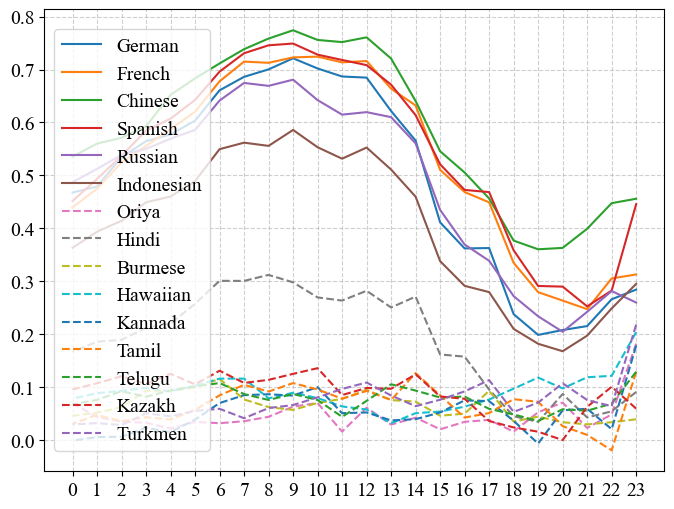

In [58]:
print_weights_layers('opinion', "Qwen/Qwen1.5-1.8B")

opinion Qwen/Qwen1.5-0.5B


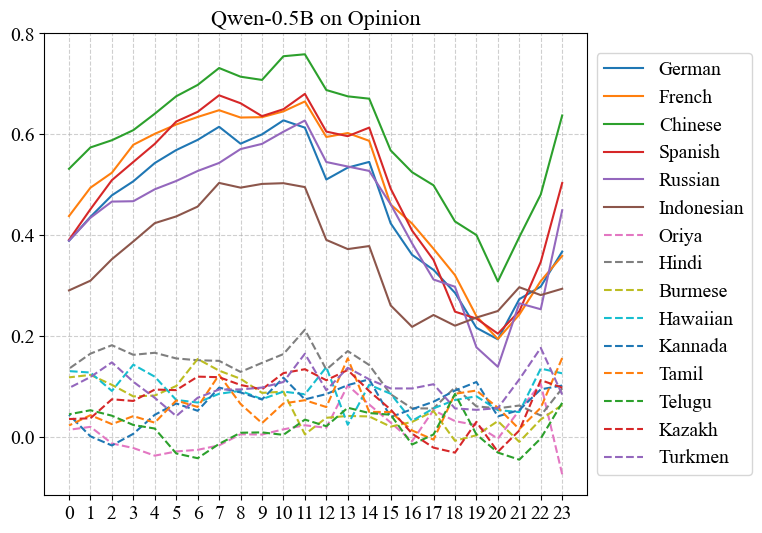

opinion Qwen/Qwen1.5-1.8B


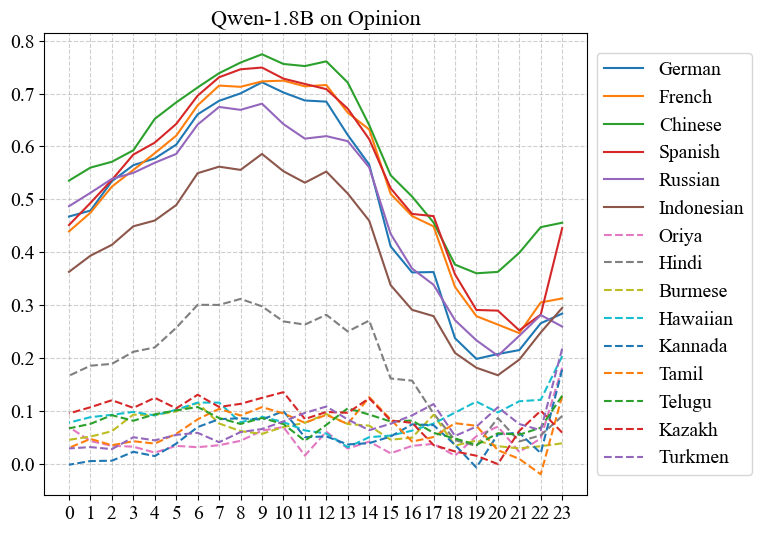

opinion google/gemma-2b


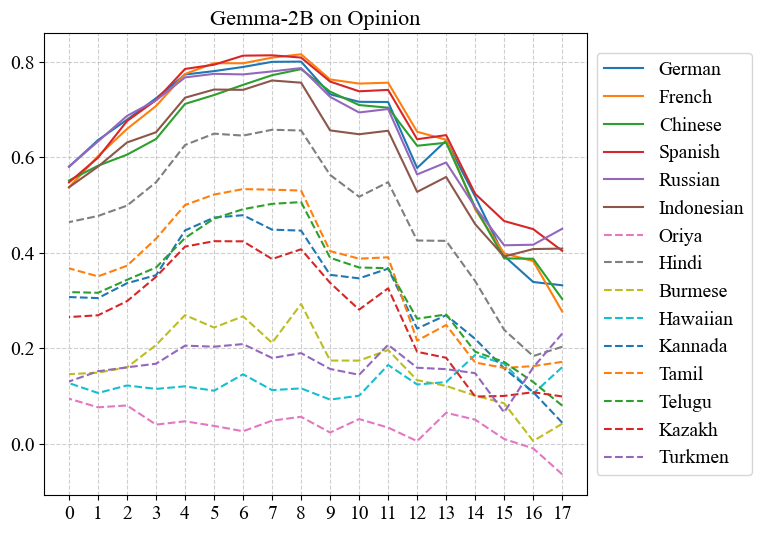

cities Qwen/Qwen1.5-0.5B


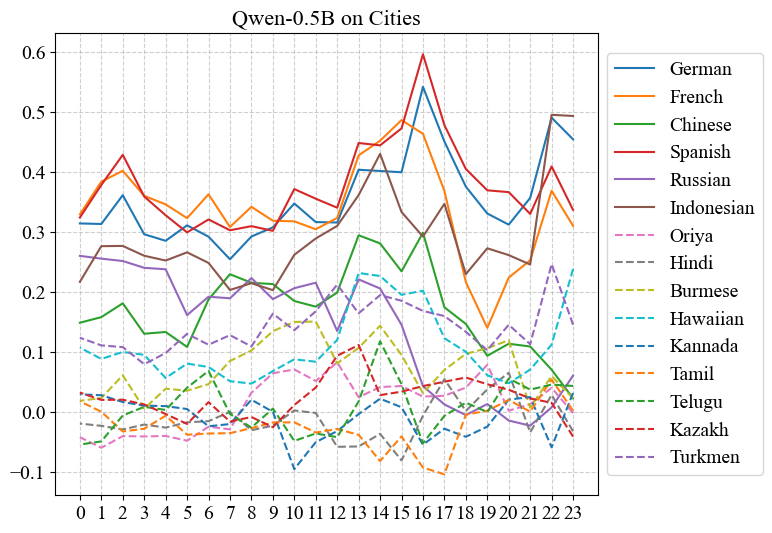

cities Qwen/Qwen1.5-1.8B


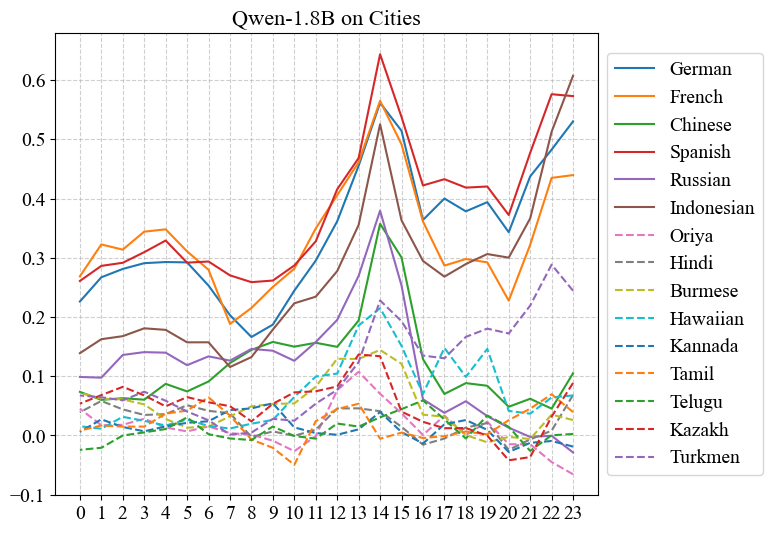

cities google/gemma-2b


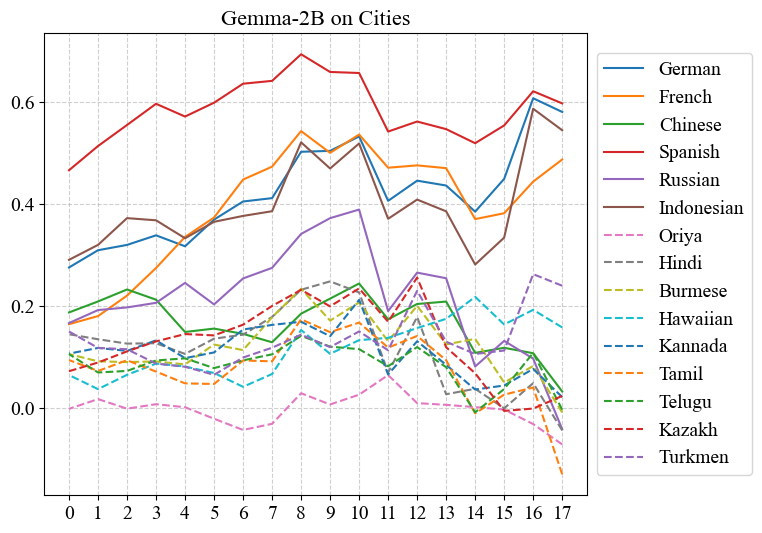

In [21]:
dataset = ['opinion', 'cities']
model = ["Qwen/Qwen1.5-0.5B", "Qwen/Qwen1.5-1.8B", "google/gemma-2b"]
# model = ['Qwen/Qwen1.5-7B', 'google/gemma-7b']

for d in dataset:
    for m in model:
        print(d, m)
        try:
            print_weights_layers(d, m)
        except Exception as e:  # Catch any exception and store it in `e`
            print(f"An error occurred with dataset '{d}' and model '{m}': {e}")
            continue  # Continue to the next iteration after logging the error

In [3]:
dic = read_weights("results/weights/opinion/opinion_Qwen-0.5b_0.txt")

In [7]:
for i in range(1):
    for language, array_data in read_weights(f"results_new/weights/opinion/opinion_Qwen-7b_{i}_new.txt").items():
        print(f'{language}: {array_data.shape}')
#         print(array_data)
    print("-------------")

English: (4096,)
German: (4096,)
French: (4096,)
Chinese: (4096,)
Spanish: (4096,)
Russian: (4096,)
Indonesian: (4096,)
Hindi: (4096,)
Hawaiian: (4096,)
Tamil: (4096,)
Kazakh: (4096,)
Turkmen: (4096,)
Burmese: (4096,)
Oriya: (4096,)
Kannada: (4096,)
Telugu: (4096,)
-------------


In [2]:
def read_weights(filename):
    weights_dict = {}
    current_language = None
    weights = []

    with open(filename, 'r') as file:
        for line in file:
            # Detect a new model and language block
            if line.startswith("Model:"):
                # Extract weights if already gathered for previous language
                if current_language and weights:
                    flattened_weights = [item for sublist in weights for item in sublist]
                    weights_dict[current_language] = np.array(flattened_weights)
                
                # Reset for new language and model
                parts = line.split(',')
                current_language = None
                weights = []
                
                for part in parts:
                    if part.strip().startswith("Language:"):
                        current_language = part.split(': ')[-1].strip()
                    if part.strip().startswith("Weights:"):
                        # Handle weights on the same line as "Model"
                        clean_line = part.replace('Weights:', '').replace('[', '').replace(']', '').strip()
                        if clean_line:
                            weights.append(list(map(float, clean_line.split())))

            # Process any subsequent lines containing weights
            elif any(char.isdigit() for char in line):
                clean_line = line.replace(']', '').replace('[', '').replace(',', '').strip()
                if clean_line:
                    weights.append(list(map(float, clean_line.split())))

        # Ensure the last language block is added to the dictionary
        if current_language and weights:
            flattened_weights = [item for sublist in weights for item in sublist]
            weights_dict[current_language] = np.array(flattened_weights)

    return weights_dict

def cosine_similarity(weights1, weights2):
    # 直接计算两个一维向量的余弦相似度
    similarity = 1 - cosine(weights1, weights2)
    return similarity